In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("../data/pseudo_labeled_tickets.csv")

In [3]:
y = df["Mismatch_Label"]

In [4]:
X_dummy = df[["Semantic_Score"]]

X_train_idx, X_test_idx, y_train, y_test = train_test_split(
    X_dummy.index,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
def evaluate_features(feature_cols):

    X = df[feature_cols]

    X_train = X.loc[X_train_idx]
    X_test = X.loc[X_test_idx]

    model = LogisticRegression(
        max_iter=1000
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    return accuracy_score(
        y_test,
        pred
    )

In [6]:
semantic_acc = evaluate_features(
    ["Semantic_Score"]
)

In [7]:
keyword_acc = evaluate_features(
    ["Keyword_Score"]
)

In [8]:
resolution_acc = evaluate_features(
    ["Resolution_Time_Hours"]
)

In [9]:
semantic_keyword_acc = evaluate_features(
    [
        "Semantic_Score",
        "Keyword_Score"
    ]
)

In [10]:
semantic_resolution_acc = evaluate_features(
    [
        "Semantic_Score",
        "Resolution_Time_Hours"
    ]
)

In [11]:
keyword_resolution_acc = evaluate_features(
    [
        "Keyword_Score",
        "Resolution_Time_Hours"
    ]
)

In [12]:
fusion_acc = evaluate_features(
    [
        "Semantic_Score",
        "Keyword_Score",
        "Resolution_Time_Hours"
    ]
)

In [13]:
results = pd.DataFrame({

    "Configuration":[

        "Semantic Only",
        "Keyword Only",
        "Resolution Only",

        "Semantic + Keyword",
        "Semantic + Resolution",
        "Keyword + Resolution",

        "Full Fusion"

    ],

    "Accuracy":[

        semantic_acc,
        keyword_acc,
        resolution_acc,

        semantic_keyword_acc,
        semantic_resolution_acc,
        keyword_resolution_acc,

        fusion_acc
    ]

})

results

,Configuration,Accuracy
0,Semantic Only,0.72800
1,Keyword Only,0.72800
2,Resolution Only,0.72800
3,Semantic + Keyword,0.75950
4,Semantic + Resolution,0.72900
5,Keyword + Resolution,0.73075
6,Full Fusion,0.73325


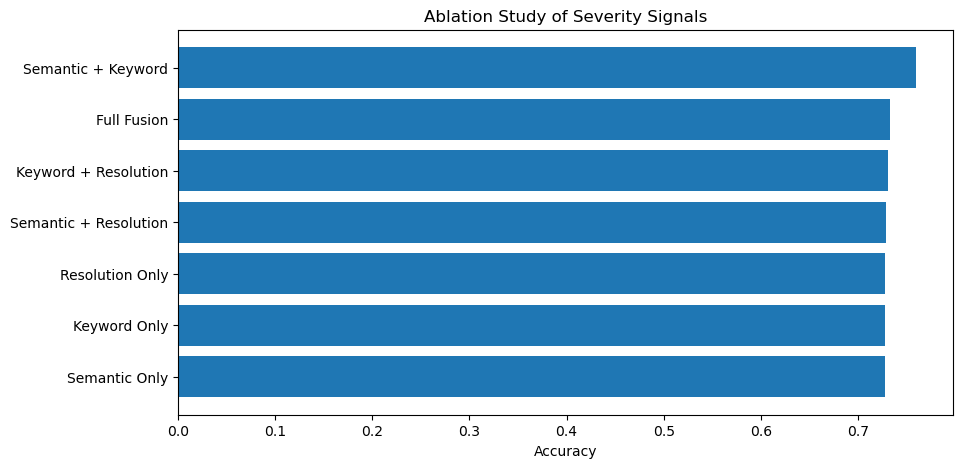

In [14]:
import matplotlib.pyplot as plt

results = results.sort_values(
    "Accuracy"
)

plt.figure(figsize=(10,5))

plt.barh(
    results["Configuration"],
    results["Accuracy"]
)

plt.xlabel("Accuracy")

plt.title(
    "Ablation Study of Severity Signals"
)

plt.show()

In [15]:
results.to_csv(
    "../data/ablation_results.csv",
    index=False
)